In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PATH = PROJECT_ROOT / "outputs" / "motif_matrix_numeric_zero_filled_v0_1.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

print("Project root:", PROJECT_ROOT)
print("Data path exists:", DATA_PATH.exists())

Project root: c:\Users\zhowa\Documents\GitHub\FloodMyth
Data path exists: True


In [2]:
df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(12, 74)


,story_id,story_name,culture,region,primary_source,source_type,story_type,overall_confidence,source_caution,notes,...,immortality_or_godlike_reward,new_rules_or_order_after_flood,population_control_after_flood,humanity_restored_after_flood,ritual_recreation_after_flood,stones_bones_blood_or_material_recreation,civilization_restored_after_flood,hydraulic_engineering_or_public_works,animal_body_or_species_origin_motif,source_biblical_influence_caution
0,FM-001,Genesis Flood / Noah,Israelite-Judahite,Levant,"Genesis 6:9–9:17, NIV",Scriptural narrative,survivor-ark flood,high,Canonical text; strong internal chronology and...,Moral corruption/violence causes flood; Noah r...,...,0.0,1.0,0.0,1.0,0.0,0.0,0.5,0.0,0.0,0.0
1,FM-002,Gilgamesh Tablet XI / Utanapishtim,Mesopotamian / Babylonian-Akkadian,Mesopotamia,"Epic of Gilgamesh, Tablet XI",Epic / mythic narrative,secret-warning ark flood,high,Cause is less explicit in Tablet XI; strong pa...,Ea secretly warns Utanapishtim through a reed ...,...,1.0,0.0,0.0,0.5,0.0,0.0,0.5,0.0,0.0,0.0
2,FM-003,Atrahasis Flood,Mesopotamian / Akkadian-Babylonian,Mesopotamia,Atrahasis flood account,Epic / mythic narrative,noise-cause survivor flood,medium,Fragmentary sections; several aftermath detail...,Humans are created to serve gods; population/n...,...,0.0,1.0,1.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0
3,FM-004,Eridu Genesis / Ziusudra,Sumerian / Mesopotamian,Mesopotamia,Eridu Genesis / Ziusudra flood account,Sumerian mythic narrative,king-priest secret-warning flood,medium,Significant lacunae; boat details and some aft...,Ziusudra is a pious king-priest/seer warned in...,...,1.0,0.0,0.0,0.5,0.0,0.0,0.5,0.0,0.0,0.0
4,FM-005,Deucalion and Pyrrha,Greek / Mediterranean,Greece,"Apollodorus, Library 1.7.2",Mythographic summary,survivor-chest flood,high,Moral cause less developed in Apollodorus than...,Prometheus advises Deucalion; Deucalion and Py...,...,0.0,0.5,0.0,1.0,0.0,1.0,0.5,0.0,0.0,0.0


In [3]:
metadata_cols = [
    "story_id",
    "story_name",
    "culture",
    "region",
    "primary_source",
    "source_type",
    "story_type",
    "overall_confidence",
    "source_caution",
    "notes",
    "include_in_core_analysis",
    "analysis_group",
    "recommended_first_visual",
    "score_notes",
]

score_cols = [
    "present_motif_score",
    "uncertain_or_partial_count",
    "core_survivor_package_score",
    "expanded_flood_catastrophe_score",
]

metadata_cols = [col for col in metadata_cols if col in df.columns]
score_cols = [col for col in score_cols if col in df.columns]

motif_cols = [
    col for col in df.columns
    if col not in metadata_cols and col not in score_cols
]

print("Motif columns:", len(motif_cols))

Motif columns: 56


In [4]:
df["story_label"] = df["story_name"].str.replace(" / ", "\n", regex=False)

df[["story_id", "story_name", "story_type", "include_in_core_analysis"]]

,story_id,story_name,story_type,include_in_core_analysis
0,FM-001,Genesis Flood / Noah,survivor-ark flood,yes
1,FM-002,Gilgamesh Tablet XI / Utanapishtim,secret-warning ark flood,yes
2,FM-003,Atrahasis Flood,noise-cause survivor flood,yes
3,FM-004,Eridu Genesis / Ziusudra,king-priest secret-warning flood,yes
4,FM-005,Deucalion and Pyrrha,survivor-chest flood,yes
5,FM-006,Manu and the Fish,animal-helper ritual-recreation flood,yes
6,FM-007,Yu Controls the Flood,flood-control civilization-restoration myth,no
7,FM-008,Popol Vuh / Destruction of the Wooden People,failed-creation destruction flood,no
8,FM-009,Huarochirí / The Llama Warns of the Flood,animal-warning mountain-refuge flood,caution
9,FM-010,Nahui Atl / Tata and Nene,world-age flood with survivor transformation,no


In [5]:
def make_similarity_dataframe(story_labels, similarity_array):
    return pd.DataFrame(
        similarity_array,
        index=story_labels,
        columns=story_labels,
    )


def plot_similarity_matrix(similarity_df, title, output_path):
    plt.figure(figsize=(10, 8))

    plt.imshow(similarity_df.values, aspect="auto", interpolation="nearest", vmin=0, vmax=1)

    plt.xticks(
        ticks=np.arange(len(similarity_df.columns)),
        labels=similarity_df.columns,
        rotation=90,
        fontsize=8,
    )

    plt.yticks(
        ticks=np.arange(len(similarity_df.index)),
        labels=similarity_df.index,
        fontsize=8,
    )

    plt.title(title, fontsize=15)
    plt.colorbar(label="Similarity score")

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    return output_path


def jaccard_similarity(binary_matrix):
    """
    Jaccard similarity = shared present motifs / motifs present in either story.

    This avoids counting shared absences as similarity.
    """
    X = binary_matrix.astype(bool)

    intersection = np.logical_and(X[:, None, :], X[None, :, :]).sum(axis=2)
    union = np.logical_or(X[:, None, :], X[None, :, :]).sum(axis=2)

    return np.divide(
        intersection,
        union,
        out=np.zeros_like(intersection, dtype=float),
        where=union != 0,
    )

In [6]:
core_df = df[df["include_in_core_analysis"].str.lower() == "yes"].copy()

core_matrix = core_df[motif_cols].astype(float).to_numpy()
core_labels = core_df["story_name"].tolist()

core_cosine = cosine_similarity(core_matrix)

core_cosine_df = make_similarity_dataframe(core_labels, core_cosine)

core_cosine_df

,Genesis Flood / Noah,Gilgamesh Tablet XI / Utanapishtim,Atrahasis Flood,Eridu Genesis / Ziusudra,Deucalion and Pyrrha,Manu and the Fish
Genesis Flood / Noah,1.000000,0.806167,0.591138,0.598421,0.594418,0.594318
Gilgamesh Tablet XI / Utanapishtim,0.806167,1.000000,0.667135,0.743985,0.542709,0.559812
Atrahasis Flood,0.591138,0.667135,1.000000,0.666682,0.405442,0.365699
Eridu Genesis / Ziusudra,0.598421,0.743985,0.666682,1.000000,0.630887,0.529695
Deucalion and Pyrrha,0.594418,0.542709,0.405442,0.630887,1.000000,0.631383
Manu and the Fish,0.594318,0.559812,0.365699,0.529695,0.631383,1.000000


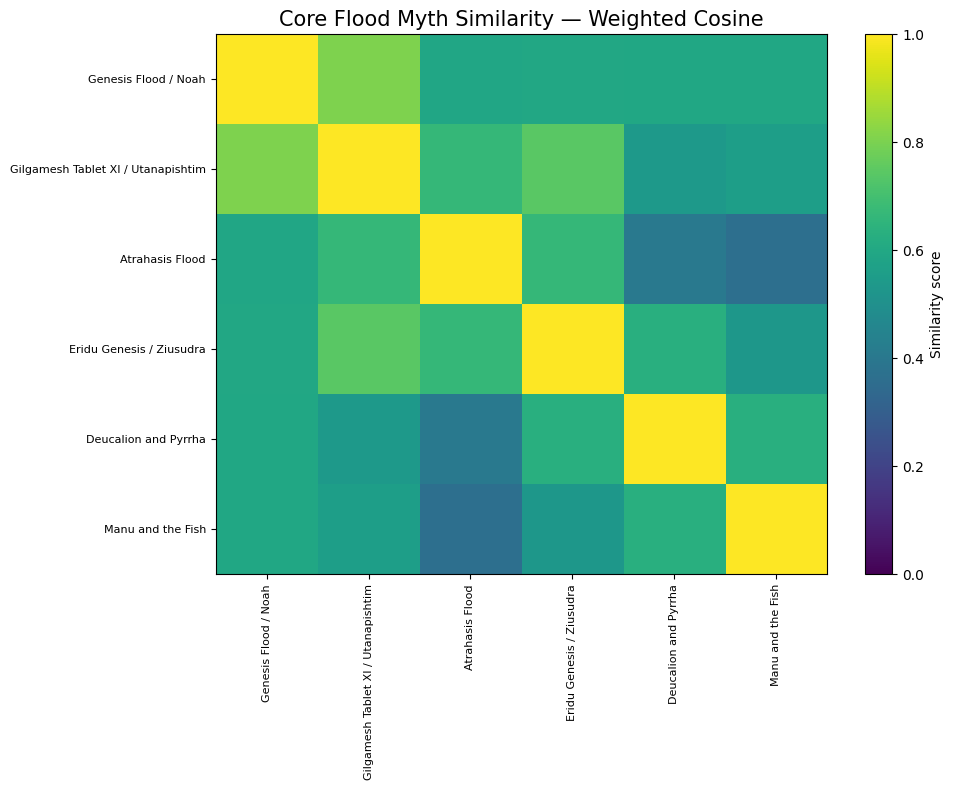

WindowsPath('c:/Users/zhowa/Documents/GitHub/FloodMyth/outputs/core_cosine_similarity_v0_1.png')

In [7]:
core_cosine_path = OUTPUT_DIR / "core_cosine_similarity_v0_1.png"

plot_similarity_matrix(
    core_cosine_df,
    "Core Flood Myth Similarity — Weighted Cosine",
    core_cosine_path,
)

In [8]:
expanded_matrix = df[motif_cols].astype(float).to_numpy()
expanded_labels = df["story_name"].tolist()

expanded_cosine = cosine_similarity(expanded_matrix)

expanded_cosine_df = make_similarity_dataframe(expanded_labels, expanded_cosine)

expanded_cosine_df

,Genesis Flood / Noah,Gilgamesh Tablet XI / Utanapishtim,Atrahasis Flood,Eridu Genesis / Ziusudra,Deucalion and Pyrrha,Manu and the Fish,Yu Controls the Flood,Popol Vuh / Destruction of the Wooden People,Huarochirí / The Llama Warns of the Flood,Nahui Atl / Tata and Nene,Bergelmir and the Blood Flood,Nuʻu and the Hawaiian Flood
Genesis Flood / Noah,1.000000,0.806167,0.591138,0.598421,0.594418,0.594318,0.135263,0.252101,0.518084,0.482673,0.289581,0.613874
Gilgamesh Tablet XI / Utanapishtim,0.806167,1.000000,0.667135,0.743985,0.542709,0.559812,0.139262,0.259554,0.457200,0.452769,0.268328,0.526685
Atrahasis Flood,0.591138,0.667135,1.000000,0.666682,0.405442,0.365699,0.081497,0.341758,0.356742,0.413601,0.348949,0.383562
Eridu Genesis / Ziusudra,0.598421,0.743985,0.666682,1.000000,0.630887,0.529695,0.141653,0.301726,0.413377,0.423634,0.207950,0.530625
Deucalion and Pyrrha,0.594418,0.542709,0.405442,0.630887,1.000000,0.631383,0.201008,0.318439,0.469271,0.663080,0.447545,0.635193
Manu and the Fish,0.594318,0.559812,0.365699,0.529695,0.631383,1.000000,0.135978,0.105597,0.595224,0.546324,0.388148,0.594261
Yu Controls the Flood,0.135263,0.139262,0.081497,0.141653,0.201008,0.135978,1.000000,0.169435,0.176863,0.230684,0.207600,0.244491
Popol Vuh / Destruction of the Wooden People,0.252101,0.259554,0.341758,0.301726,0.318439,0.105597,0.169435,1.000000,0.247226,0.412030,0.241825,0.170879
Huarochirí / The Llama Warns of the Flood,0.518084,0.457200,0.356742,0.413377,0.469271,0.595224,0.176863,0.247226,1.000000,0.504893,0.189321,0.579705
Nahui Atl / Tata and Nene,0.482673,0.452769,0.413601,0.423634,0.663080,0.546324,0.230684,0.412030,0.504893,1.000000,0.526789,0.542851


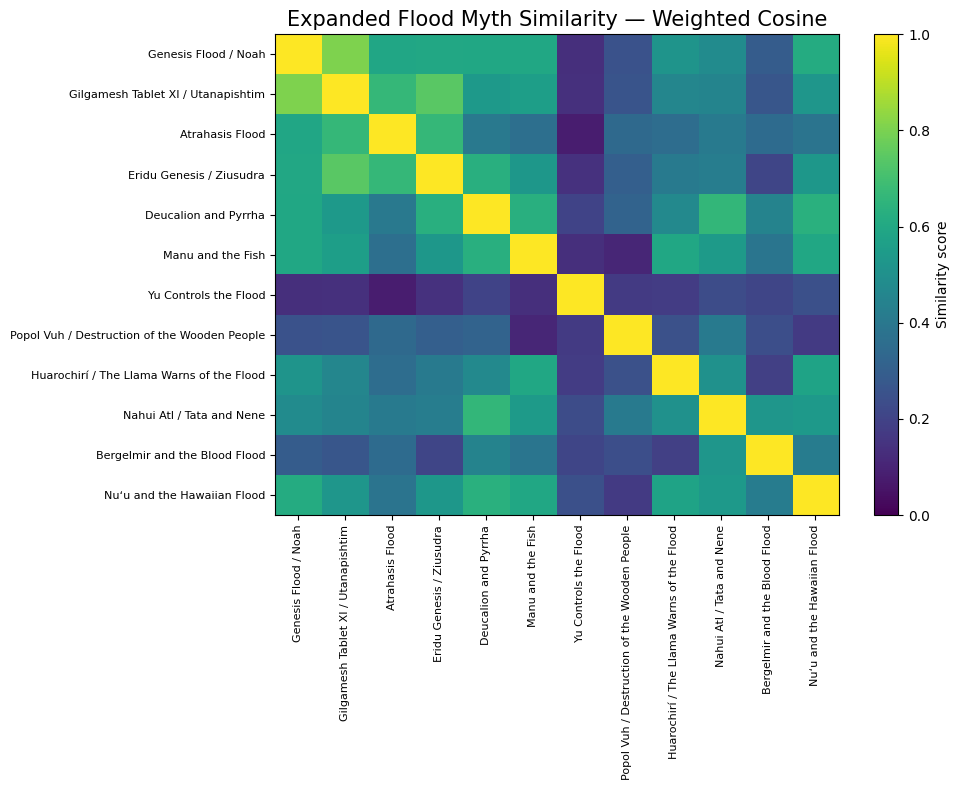

WindowsPath('c:/Users/zhowa/Documents/GitHub/FloodMyth/outputs/expanded_cosine_similarity_v0_1.png')

In [9]:
expanded_cosine_path = OUTPUT_DIR / "expanded_cosine_similarity_v0_1.png"

plot_similarity_matrix(
    expanded_cosine_df,
    "Expanded Flood Myth Similarity — Weighted Cosine",
    expanded_cosine_path,
)

In [10]:
binary_matrix = (df[motif_cols].astype(float).to_numpy() > 0).astype(int)

expanded_jaccard = jaccard_similarity(binary_matrix)

expanded_jaccard_df = make_similarity_dataframe(expanded_labels, expanded_jaccard)

expanded_jaccard_df

,Genesis Flood / Noah,Gilgamesh Tablet XI / Utanapishtim,Atrahasis Flood,Eridu Genesis / Ziusudra,Deucalion and Pyrrha,Manu and the Fish,Yu Controls the Flood,Popol Vuh / Destruction of the Wooden People,Huarochirí / The Llama Warns of the Flood,Nahui Atl / Tata and Nene,Bergelmir and the Blood Flood,Nuʻu and the Hawaiian Flood
Genesis Flood / Noah,1.000000,0.696970,0.424242,0.457143,0.441176,0.406250,0.088235,0.147059,0.323529,0.358974,0.142857,0.432432
Gilgamesh Tablet XI / Utanapishtim,0.696970,1.000000,0.468750,0.593750,0.400000,0.363636,0.088235,0.114286,0.285714,0.358974,0.142857,0.358974
Atrahasis Flood,0.424242,0.468750,1.000000,0.448276,0.290323,0.241379,0.037037,0.200000,0.241379,0.294118,0.192308,0.257143
Eridu Genesis / Ziusudra,0.457143,0.593750,0.448276,1.000000,0.517241,0.379310,0.142857,0.133333,0.290323,0.297297,0.093750,0.371429
Deucalion and Pyrrha,0.441176,0.400000,0.290323,0.517241,1.000000,0.520000,0.153846,0.185185,0.310345,0.533333,0.320000,0.483871
Manu and the Fish,0.406250,0.363636,0.241379,0.379310,0.520000,1.000000,0.130435,0.076923,0.360000,0.400000,0.260870,0.354839
Yu Controls the Flood,0.088235,0.088235,0.037037,0.142857,0.153846,0.130435,1.000000,0.111111,0.130435,0.172414,0.105263,0.172414
Popol Vuh / Destruction of the Wooden People,0.147059,0.114286,0.200000,0.133333,0.185185,0.076923,0.111111,1.000000,0.166667,0.241379,0.150000,0.125000
Huarochirí / The Llama Warns of the Flood,0.323529,0.285714,0.241379,0.290323,0.310345,0.360000,0.130435,0.166667,1.000000,0.312500,0.115385,0.354839
Nahui Atl / Tata and Nene,0.358974,0.358974,0.294118,0.297297,0.533333,0.400000,0.172414,0.241379,0.312500,1.000000,0.321429,0.428571


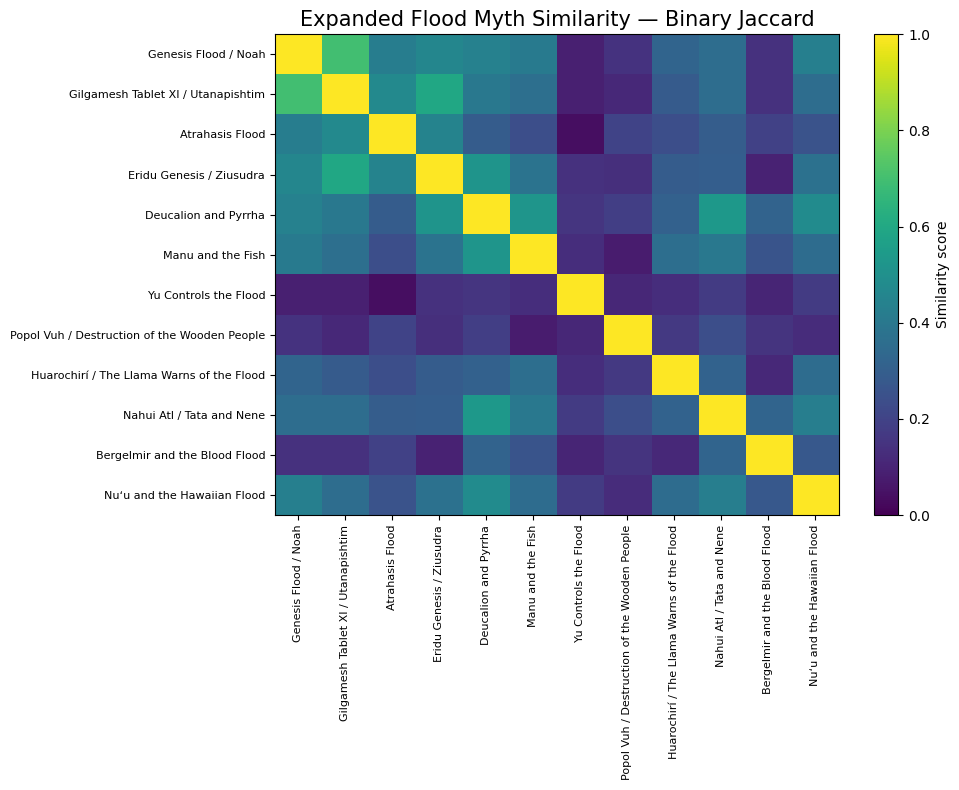

WindowsPath('c:/Users/zhowa/Documents/GitHub/FloodMyth/outputs/expanded_jaccard_similarity_v0_1.png')

In [11]:
expanded_jaccard_path = OUTPUT_DIR / "expanded_jaccard_similarity_v0_1.png"

plot_similarity_matrix(
    expanded_jaccard_df,
    "Expanded Flood Myth Similarity — Binary Jaccard",
    expanded_jaccard_path,
)

In [12]:
def get_top_similarity_pairs(similarity_df, top_n=20):
    pairs = []

    labels = similarity_df.index.tolist()

    for i, story_a in enumerate(labels):
        for j, story_b in enumerate(labels):
            if j <= i:
                continue

            pairs.append(
                {
                    "story_a": story_a,
                    "story_b": story_b,
                    "similarity": similarity_df.iloc[i, j],
                }
            )

    return (
        pd.DataFrame(pairs)
        .sort_values("similarity", ascending=False)
        .reset_index(drop=True)
        .head(top_n)
    )


top_cosine_pairs = get_top_similarity_pairs(expanded_cosine_df, top_n=20)
top_jaccard_pairs = get_top_similarity_pairs(expanded_jaccard_df, top_n=20)

top_cosine_pairs

,story_a,story_b,similarity
0,Genesis Flood / Noah,Gilgamesh Tablet XI / Utanapishtim,0.806167
1,Gilgamesh Tablet XI / Utanapishtim,Eridu Genesis / Ziusudra,0.743985
2,Gilgamesh Tablet XI / Utanapishtim,Atrahasis Flood,0.667135
3,Atrahasis Flood,Eridu Genesis / Ziusudra,0.666682
4,Deucalion and Pyrrha,Nahui Atl / Tata and Nene,0.663080
5,Deucalion and Pyrrha,Nuʻu and the Hawaiian Flood,0.635193
6,Deucalion and Pyrrha,Manu and the Fish,0.631383
7,Eridu Genesis / Ziusudra,Deucalion and Pyrrha,0.630887
8,Genesis Flood / Noah,Nuʻu and the Hawaiian Flood,0.613874
9,Genesis Flood / Noah,Eridu Genesis / Ziusudra,0.598421


In [13]:
top_jaccard_pairs

,story_a,story_b,similarity
0,Genesis Flood / Noah,Gilgamesh Tablet XI / Utanapishtim,0.696970
1,Gilgamesh Tablet XI / Utanapishtim,Eridu Genesis / Ziusudra,0.593750
2,Deucalion and Pyrrha,Nahui Atl / Tata and Nene,0.533333
3,Deucalion and Pyrrha,Manu and the Fish,0.520000
4,Eridu Genesis / Ziusudra,Deucalion and Pyrrha,0.517241
5,Deucalion and Pyrrha,Nuʻu and the Hawaiian Flood,0.483871
6,Gilgamesh Tablet XI / Utanapishtim,Atrahasis Flood,0.468750
7,Genesis Flood / Noah,Eridu Genesis / Ziusudra,0.457143
8,Atrahasis Flood,Eridu Genesis / Ziusudra,0.448276
9,Genesis Flood / Noah,Deucalion and Pyrrha,0.441176


In [14]:
core_cosine_csv_path = OUTPUT_DIR / "core_cosine_similarity_v0_1.csv"
expanded_cosine_csv_path = OUTPUT_DIR / "expanded_cosine_similarity_v0_1.csv"
expanded_jaccard_csv_path = OUTPUT_DIR / "expanded_jaccard_similarity_v0_1.csv"
top_cosine_pairs_path = OUTPUT_DIR / "top_cosine_similarity_pairs_v0_1.csv"
top_jaccard_pairs_path = OUTPUT_DIR / "top_jaccard_similarity_pairs_v0_1.csv"

core_cosine_df.to_csv(core_cosine_csv_path)
expanded_cosine_df.to_csv(expanded_cosine_csv_path)
expanded_jaccard_df.to_csv(expanded_jaccard_csv_path)
top_cosine_pairs.to_csv(top_cosine_pairs_path, index=False)
top_jaccard_pairs.to_csv(top_jaccard_pairs_path, index=False)

print("Saved:")
print(core_cosine_csv_path)
print(expanded_cosine_csv_path)
print(expanded_jaccard_csv_path)
print(top_cosine_pairs_path)
print(top_jaccard_pairs_path)

Saved:
c:\Users\zhowa\Documents\GitHub\FloodMyth\outputs\core_cosine_similarity_v0_1.csv
c:\Users\zhowa\Documents\GitHub\FloodMyth\outputs\expanded_cosine_similarity_v0_1.csv
c:\Users\zhowa\Documents\GitHub\FloodMyth\outputs\expanded_jaccard_similarity_v0_1.csv
c:\Users\zhowa\Documents\GitHub\FloodMyth\outputs\top_cosine_similarity_pairs_v0_1.csv
c:\Users\zhowa\Documents\GitHub\FloodMyth\outputs\top_jaccard_similarity_pairs_v0_1.csv
